# Руководство пользователя

В данном ноутбуке приведена как установка зависимостей программы, так и эксперименты и сама программа. Данный ноутбук можно выполнять в Google Colab с версией среды выполнения **2025.07**, типом среды выполнения **Python 3**, аппаратным ускорителем - **Графический процессор Т4**.

Перед началом работы обязательно запустить все ячейки из секции **Установка зависимостей**.

Далее можно просмотреть результаты экспериментов, проведенных с данными. Для этого в основную папку в ноутбуке загружалась папка data с файлами Train_{i}.jpg внутри. Секцию **Эксперименты** запускать не обязательно.

Для использования самой программы перейдите к секции **Программа** и запустите её. После этого появится интерфейс, полностью готовый к работе.

# Установка зависимостей

In [1]:
!nvidia-smi

Fri Mar 13 16:27:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
import torch
print(f"Версия PyTorch: {torch.__version__}")

Версия PyTorch: 2.6.0+cu124


In [4]:
%cd {HOME}
!git clone https://github.com/IDEA-Research/GroundingDINO.git

%cd {HOME}/GroundingDINO/groundingdino/models/GroundingDINO/csrc/MsDeformAttn
!sed -i 's/value.type()/value.scalar_type()/g' ms_deform_attn_cuda.cu
!sed -i 's/value.scalar_type().is_cuda()/value.is_cuda()/g' ms_deform_attn_cuda.cu

/content
Cloning into 'GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 12.91 MiB | 16.32 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO/groundingdino/models/GroundingDINO/csrc/MsDeformAttn


In [5]:
%cd {HOME}/GroundingDINO
!pip install -q -e .
!pip install -q roboflow

/content/GroundingDINO
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5

In [3]:
import os

CONFIG_PATH = os.path.join(HOME, "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py")
print(CONFIG_PATH, "; exist:", os.path.isfile(CONFIG_PATH))

/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py ; exist: True


In [7]:
%cd {HOME}
!mkdir {HOME}/weights
%cd {HOME}/weights

!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth

/content
/content/weights


In [4]:
import os

WEIGHTS_NAME = "groundingdino_swint_ogc.pth"
WEIGHTS_PATH = os.path.join(HOME, "weights", WEIGHTS_NAME)
print(WEIGHTS_PATH, "; exist:", os.path.isfile(WEIGHTS_PATH))

/content/weights/groundingdino_swint_ogc.pth ; exist: True


In [5]:
%cd {HOME}/GroundingDINO

from groundingdino.util.inference import load_model, load_image, predict, annotate

model = load_model(CONFIG_PATH, WEIGHTS_PATH)

/content/GroundingDINO


final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


# Эксперименты

In [23]:
import random

def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(42)

In [20]:
import os
import supervision as sv
import numpy as np
import warnings
warnings.filterwarnings('ignore')

real_counts = [22, 22, 16, 22, 13, 15, 22, 13, 13, 14, 26, 16, 20]
real_eggs = [0, 0, 16, 22, 13, 15, 11, 13, 0, 14, 14, 16, 0]
real_tomatoes = [22, 22, 0, 0, 0, 0, 11, 0, 13, 0, 12, 0, 20]

PROMPTS = ["food", "tomato", "egg", "fruit", "vegetable", "round object", "oval object", "cherry", "plum"]
BOX_TRESHOLD = 0.15
TEXT_TRESHOLD = 0.15
IOU_THRESHOLD = 0.3

TEXT_PROMPT_TOMATO = "orange . tomato . red . plum . cherry . pink"
BOX_TRESHOLD_TOMATO = 0.30
TEXT_TRESHOLD_TOMATO = 0.25

def compute_overlap(box1, box2):
    x1_1 = box1[0] - box1[2]/2
    y1_1 = box1[1] - box1[3]/2
    x2_1 = box1[0] + box1[2]/2
    y2_1 = box1[1] + box1[3]/2

    x1_2 = box2[0] - box2[2]/2
    y1_2 = box2[1] - box2[3]/2
    x2_2 = box2[0] + box2[2]/2
    y2_2 = box2[1] + box2[3]/2

    x_left = max(x1_1, x1_2)
    y_top = max(y1_1, y1_2)
    x_right = min(x2_1, x2_2)
    y_bottom = min(y2_1, y2_2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    min_area = min(area1, area2)

    return intersection / min_area if min_area > 0 else 0.0

losses = []

for i in range(1, 14):
    IMAGE_NAME = f"Train_{i}.jpg"
    IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

    try:
        image_source, image = load_image(IMAGE_PATH)

        all_boxes = []
        all_logits = []
        all_phrases = []

        for prompt in PROMPTS:
            boxes, logits, phrases = predict(
                model=model,
                image=image,
                caption=prompt,
                box_threshold=BOX_TRESHOLD,
                text_threshold=TEXT_TRESHOLD
            )

            if len(boxes) > 0:
                all_boxes.extend(boxes)
                all_logits.extend(logits)
                all_phrases.extend(phrases)

        unique_boxes = []
        unique_logits = []
        unique_phrases = []

        box_sizes = [box[2] * box[3] for box in all_boxes]
        sorted_indices = np.argsort(box_sizes)

        for idx in sorted_indices:
            box = all_boxes[idx]
            is_unique = True

            for existing_box in unique_boxes:
                if compute_overlap(box, existing_box) > IOU_THRESHOLD:
                    is_unique = False
                    break

            if is_unique:
                unique_boxes.append(box)
                unique_logits.append(all_logits[idx])
                unique_phrases.append(all_phrases[idx])

        detected = len(unique_boxes)
        real = real_counts[i-1]

        boxes_tomato, logits_tomato, phrases_tomato = predict(
          model=model,
          image=image,
          caption=TEXT_PROMPT_TOMATO,
          box_threshold=BOX_TRESHOLD_TOMATO,
          text_threshold=TEXT_TRESHOLD_TOMATO
        )

        tomatoes = len(boxes_tomato)
        eggs = detected - tomatoes
        real_tomato = real_tomatoes[i-1]
        real_egg = real_eggs[i-1]

        loss = abs(real_tomato - tomatoes) + abs(real_egg - eggs)
        losses.append(loss)

        print(f"Train_{i}: обнаружено всего: {detected}, по факту всего: {detected}/{real}, томатов: {tomatoes}/{real_tomato}, яиц: {eggs}/{real_egg}, loss: {loss}")

    except Exception as e:
        print(f"Ошибка при обработке Train_{i}: {e}")
        losses.append(np.nan)

avg_loss = np.nanmean(losses)
print(f"\nФинальный train loss: {avg_loss:.2f}")

print("\nАнализ завершен!")

Train_1: обнаружено всего: 22, по факту всего: 22/22, томатов: 22/22, яиц: 0/0, loss: 0
Train_2: обнаружено всего: 22, по факту всего: 22/22, томатов: 22/22, яиц: 0/0, loss: 0
Train_3: обнаружено всего: 16, по факту всего: 16/16, томатов: 0/0, яиц: 16/16, loss: 0
Train_4: обнаружено всего: 22, по факту всего: 22/22, томатов: 0/0, яиц: 22/22, loss: 0
Train_5: обнаружено всего: 13, по факту всего: 13/13, томатов: 0/0, яиц: 13/13, loss: 0
Train_6: обнаружено всего: 15, по факту всего: 15/15, томатов: 0/0, яиц: 15/15, loss: 0
Train_7: обнаружено всего: 22, по факту всего: 22/22, томатов: 12/11, яиц: 10/11, loss: 2
Train_8: обнаружено всего: 13, по факту всего: 13/13, томатов: 0/0, яиц: 13/13, loss: 0
Train_9: обнаружено всего: 13, по факту всего: 13/13, томатов: 13/13, яиц: 0/0, loss: 0
Train_10: обнаружено всего: 14, по факту всего: 14/14, томатов: 0/0, яиц: 14/14, loss: 0
Train_11: обнаружено всего: 27, по факту всего: 27/26, томатов: 6/12, яиц: 21/14, loss: 13
Train_12: обнаружено всего

In [21]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 40.3 MB/s eta 0:00:00


In [24]:
import optuna

def objective(trial):
    BOX_TRESHOLD = trial.suggest_float('BOX_TRESHOLD', 0.05, 0.5)
    TEXT_TRESHOLD = trial.suggest_float('TEXT_TRESHOLD', 0.05, 0.5)
    IOU_THRESHOLD = trial.suggest_float('IOU_THRESHOLD', 0.1, 0.7)
    BOX_TRESHOLD_TOMATO = trial.suggest_float('BOX_TRESHOLD_TOMATO', 0.1, 0.5)
    TEXT_TRESHOLD_TOMATO = trial.suggest_float('TEXT_TRESHOLD_TOMATO', 0.1, 0.5)

    losses = []

    for i in range(1, 14):
        IMAGE_NAME = f"Train_{i}.jpg"
        IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

        try:
            image_source, image = load_image(IMAGE_PATH)

            all_boxes = []
            all_logits = []
            all_phrases = []

            for prompt in PROMPTS:
                boxes, logits, phrases = predict(
                    model=model,
                    image=image,
                    caption=prompt,
                    box_threshold=BOX_TRESHOLD,
                    text_threshold=TEXT_TRESHOLD
                )

                if len(boxes) > 0:
                    all_boxes.extend(boxes)
                    all_logits.extend(logits)
                    all_phrases.extend(phrases)

            unique_boxes = []
            unique_logits = []
            unique_phrases = []

            box_sizes = [box[2] * box[3] for box in all_boxes]
            sorted_indices = np.argsort(box_sizes)

            for idx in sorted_indices:
                box = all_boxes[idx]
                is_unique = True

                for existing_box in unique_boxes:
                    if compute_overlap(box, existing_box) > IOU_THRESHOLD:
                        is_unique = False
                        break

                if is_unique:
                    unique_boxes.append(box)
                    unique_logits.append(all_logits[idx])
                    unique_phrases.append(all_phrases[idx])

            detected = len(unique_boxes)

            boxes_tomato, logits_tomato, phrases_tomato = predict(
                model=model,
                image=image,
                caption=TEXT_PROMPT_TOMATO,
                box_threshold=BOX_TRESHOLD_TOMATO,
                text_threshold=TEXT_TRESHOLD_TOMATO
            )

            tomatoes = len(boxes_tomato)
            eggs = detected - tomatoes
            real_tomato = real_tomatoes[i-1]
            real_egg = real_eggs[i-1]

            loss = abs(real_tomato - tomatoes) + abs(real_egg - eggs)
            losses.append(loss)

        except Exception as e:
            losses.append(np.nan)

    return np.nanmean(losses)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры:")
print(f"BOX_TRESHOLD = {study.best_params['BOX_TRESHOLD']:.3f}")
print(f"TEXT_TRESHOLD = {study.best_params['TEXT_TRESHOLD']:.3f}")
print(f"IOU_THRESHOLD = {study.best_params['IOU_THRESHOLD']:.3f}")
print(f"BOX_TRESHOLD_TOMATO = {study.best_params['BOX_TRESHOLD_TOMATO']:.3f}")
print(f"TEXT_TRESHOLD_TOMATO = {study.best_params['TEXT_TRESHOLD_TOMATO']:.3f}")
print(f"Лучший loss: {study.best_value:.2f}")

[I 2026-03-13 17:49:38,963] A new study created in memory with name: no-name-49bdbb99-8b41-46ba-8ed3-a57e9f26cd8d
[I 2026-03-13 17:50:27,576] Trial 0 finished with value: 2.6153846153846154 and parameters: {'BOX_TRESHOLD': 0.310365767214541, 'TEXT_TRESHOLD': 0.4321544637217307, 'IOU_THRESHOLD': 0.4690764409414203, 'BOX_TRESHOLD_TOMATO': 0.33378877571992904, 'TEXT_TRESHOLD_TOMATO': 0.17769054767028433}. Best is trial 0 with value: 2.6153846153846154.
[I 2026-03-13 17:51:15,179] Trial 1 finished with value: 0.6923076923076923 and parameters: {'BOX_TRESHOLD': 0.16938586725210342, 'TEXT_TRESHOLD': 0.15049912422828177, 'IOU_THRESHOLD': 0.27553553683741494, 'BOX_TRESHOLD_TOMATO': 0.23763714572701955, 'TEXT_TRESHOLD_TOMATO': 0.1170755168167592}. Best is trial 1 with value: 0.6923076923076923.
[I 2026-03-13 17:52:04,644] Trial 2 finished with value: 6.769230769230769 and parameters: {'BOX_TRESHOLD': 0.1134493534335392, 'TEXT_TRESHOLD': 0.10686933088310863, 'IOU_THRESHOLD': 0.6765408472107066, 

Лучшие параметры:
BOX_TRESHOLD = 0.169
TEXT_TRESHOLD = 0.150
IOU_THRESHOLD = 0.276
BOX_TRESHOLD_TOMATO = 0.238
TEXT_TRESHOLD_TOMATO = 0.117
Лучший loss: 0.69


# Программа


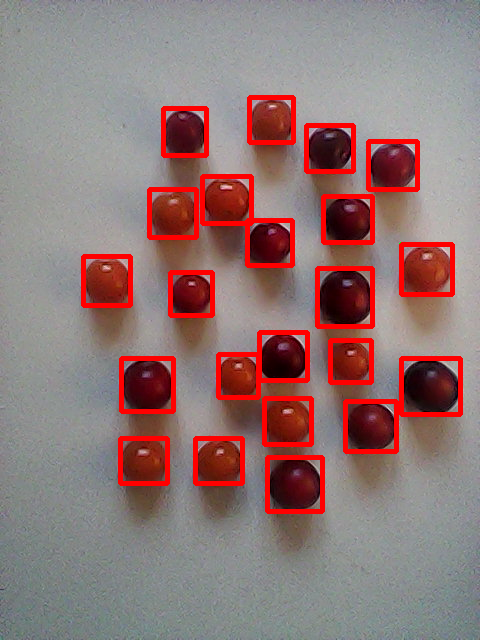


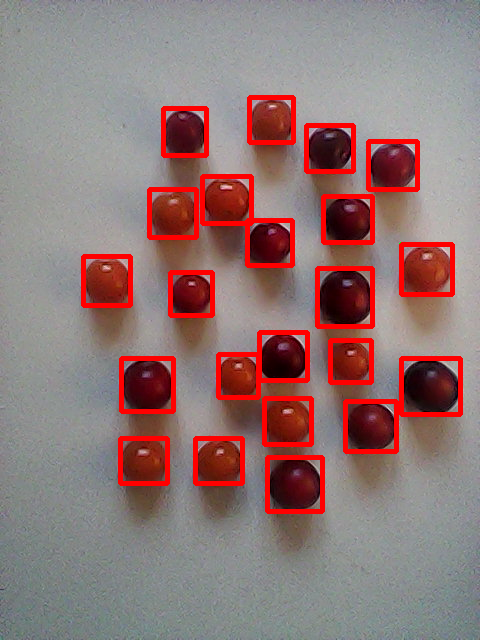

In [57]:
# @title Запуск программы
import os
import supervision as sv
import numpy as np
import warnings
import cv2
from PIL import Image as PILImage
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
import threading
import time
import sys
import random
warnings.filterwarnings('ignore')

from google.colab import output
output.enable_custom_widget_manager()

os.environ['NO_PROXY'] = 'localhost,127.0.0.1'
os.environ['no_proxy'] = 'localhost,127.0.0.1'

BOX_TRESHOLD = 0.169
TEXT_TRESHOLD = 0.15
IOU_THRESHOLD = 0.276
BOX_TRESHOLD_TOMATO = 0.238
TEXT_TRESHOLD_TOMATO = 0.117

PROMPTS = ["food", "tomato", "egg", "fruit", "vegetable", "round object", "oval object", "cherry", "plum"]
TEXT_PROMPT_TOMATO = "orange . tomato . red . plum . cherry . pink"

def compute_overlap(box1, box2):
    x1_1 = box1[0] - box1[2]/2
    y1_1 = box1[1] - box1[3]/2
    x2_1 = box1[0] + box1[2]/2
    y2_1 = box1[1] + box1[3]/2

    x1_2 = box2[0] - box2[2]/2
    y1_2 = box2[1] - box2[3]/2
    x2_2 = box2[0] + box2[2]/2
    y2_2 = box2[1] + box2[3]/2

    x_left = max(x1_1, x1_2)
    y_top = max(y1_1, y1_2)
    x_right = min(x2_1, x2_2)
    y_bottom = min(y2_1, y2_2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    min_area = min(area1, area2)

    return intersection / min_area if min_area > 0 else 0.0

def process_image_file(file_content, filename):
    try:
        temp_path = f"/tmp/{filename}"
        with open(temp_path, 'wb') as f:
            f.write(file_content)

        image_source, image = load_image(temp_path)
        image_draw = image_source.copy()

        all_boxes = []
        all_logits = []
        all_phrases = []

        for prompt in PROMPTS:
            boxes, logits, phrases = predict(
                model=model,
                image=image,
                caption=prompt,
                box_threshold=BOX_TRESHOLD,
                text_threshold=TEXT_TRESHOLD
            )

            if len(boxes) > 0:
                all_boxes.extend(boxes)
                all_logits.extend(logits)
                all_phrases.extend(phrases)

        unique_boxes = []
        unique_logits = []
        unique_phrases = []

        box_sizes = [box[2] * box[3] for box in all_boxes]
        sorted_indices = np.argsort(box_sizes)

        for idx in sorted_indices:
            box = all_boxes[idx]
            is_unique = True

            for existing_box in unique_boxes:
                if compute_overlap(box, existing_box) > IOU_THRESHOLD:
                    is_unique = False
                    break

            if is_unique:
                unique_boxes.append(box)
                unique_logits.append(all_logits[idx])
                unique_phrases.append(all_phrases[idx])

        detected = len(unique_boxes)

        boxes_tomato, logits_tomato, phrases_tomato = predict(
            model=model,
            image=image,
            caption=TEXT_PROMPT_TOMATO,
            box_threshold=BOX_TRESHOLD_TOMATO,
            text_threshold=TEXT_TRESHOLD_TOMATO
        )

        tomatoes = len(boxes_tomato)
        eggs = detected - tomatoes

        for box in unique_boxes:
            x_center, y_center, width, height = box
            x1 = int((x_center - width/2) * image_draw.shape[1])
            y1 = int((y_center - height/2) * image_draw.shape[0])
            x2 = int((x_center + width/2) * image_draw.shape[1])
            y2 = int((y_center + height/2) * image_draw.shape[0])
            cv2.rectangle(image_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)

        for box in boxes_tomato:
            x_center, y_center, width, height = box
            x1 = int((x_center - width/2) * image_draw.shape[1])
            y1 = int((y_center - height/2) * image_draw.shape[0])
            x2 = int((x_center + width/2) * image_draw.shape[1])
            y2 = int((y_center + height/2) * image_draw.shape[0])
            cv2.rectangle(image_draw, (x1, y1), (x2, y2), (255, 0, 0), 3)

        result_pil = PILImage.fromarray(image_draw)

        img_byte_arr = io.BytesIO()
        result_pil.save(img_byte_arr, format='PNG')

        os.remove(temp_path)

        return img_byte_arr.getvalue(), f"Помидоров: {tomatoes}, Яиц: {eggs}"

    except Exception as e:
        return None, f"Ошибка обработки: {str(e)}"

clear_output()

from IPython.display import HTML

upload_html = HTML('''
<div style="font-family: Arial, sans-serif; max-width: 900px; margin: 0 auto;">
    <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 15px 15px 0 0; text-align: center; color: white;">
        <h1 style="margin: 0; font-size: 2.5em;">Детектор помидоров и яиц</h1>
        <p style="margin: 10px 0 0; opacity: 0.9;">Загрузите изображение для автоматического обнаружения объектов</p>
    </div>

    <div style="background: #f8f9fa; padding: 30px; border-radius: 0 0 15px 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">

        <div style="background: white; padding: 20px; border-radius: 10px; margin-bottom: 20px; border: 2px dashed #667eea; text-align: center;">
            <h3 style="color: #333; margin-top: 0;">📁 Загрузите изображение</h3>
            <input type="file" id="fileInput" accept="image/*" style="padding: 10px; border: 1px solid #ddd; border-radius: 5px; width: 300px;">
            <br><br>
            <button onclick="processFile()" id="processBtn" disabled style="padding: 12px 30px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; border: none; border-radius: 25px; font-size: 16px; cursor: pointer; box-shadow: 0 2px 4px rgba(0,0,0,0.2); transition: transform 0.2s;">
                Обработать изображение
            </button>
        </div>

        <div style="display: flex; gap: 20px; flex-wrap: wrap; justify-content: center;">
            <div style="flex: 1; min-width: 300px; background: white; padding: 15px; border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
                <h4 style="color: #333; margin-top: 0; text-align: center;">Выбранное фото</h4>
                <div style="text-align: center; min-height: 300px; display: flex; align-items: center; justify-content: center; background: #f8f9fa; border-radius: 5px;">
                    <img id="preview" style="max-width: 100%; max-height: 300px; border-radius: 5px; display: none;">
                    <div id="placeholder" style="color: #999;">Фото не выбрано</div>
                </div>
            </div>

            <div style="flex: 1; min-width: 300px; background: white; padding: 15px; border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
                <h4 style="color: #333; margin-top: 0; text-align: center;">Результат детекции</h4>
                <div style="text-align: center; min-height: 300px; display: flex; align-items: center; justify-content: center; background: #f8f9fa; border-radius: 5px;">
                    <img id="resultImg" style="max-width: 100%; max-height: 300px; border-radius: 5px; display: none;">
                    <div id="resultPlaceholder" style="color: #999;">Ожидание обработки</div>
                </div>
            </div>
        </div>

        <div id="stats" style="margin-top: 20px; padding: 15px; background: white; border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; font-size: 20px; font-weight: bold; color: #333; display: none;">
        </div>

        <div style="margin-top: 20px; padding: 10px; background: #e8f4fd; border-radius: 5px; font-size: 14px; color: #555;">
            <span style="display: inline-block; margin-right: 20px;"><span style="color: #00ff00;">🟢</span> Зеленые рамки: яйца</span>
            <span style="display: inline-block;"><span style="color: #ff0000;">🔴</span> Красные рамки: помидоры</span>
        </div>
    </div>
</div>

<script>
let currentFile = null;

document.getElementById('fileInput').addEventListener('change', function(e) {
    currentFile = e.target.files[0];
    if (currentFile) {
        const reader = new FileReader();
        reader.onload = function(e) {
            const preview = document.getElementById('preview');
            preview.src = e.target.result;
            preview.style.display = 'block';
            document.getElementById('placeholder').style.display = 'none';
        };
        reader.readAsDataURL(currentFile);

        document.getElementById('processBtn').disabled = false;

        document.getElementById('resultImg').style.display = 'none';
        document.getElementById('resultPlaceholder').style.display = 'block';
        document.getElementById('resultPlaceholder').innerHTML = 'Ожидание обработки';
        document.getElementById('stats').style.display = 'none';
    }
});

window.processFile = function() {
    if (!currentFile) return;

    document.getElementById('resultPlaceholder').innerHTML = 'Обработка...';
    document.getElementById('stats').style.display = 'none';

    const reader = new FileReader();
    reader.onload = function(e) {
        google.colab.kernel.invokeFunction('process_image', [e.target.result], {});
    };
    reader.readAsDataURL(currentFile);
}
</script>
''')

display(upload_html)

from google.colab import output

def process_image_callback(data):
    try:
        import base64
        image_data = base64.b64decode(data.split(',')[1])

        temp_path = '/tmp/uploaded_image.jpg'
        with open(temp_path, 'wb') as f:
            f.write(image_data)

        result_img, stats = process_image_file(image_data, 'image.jpg')

        if result_img:
            result_base64 = base64.b64encode(result_img).decode('utf-8')

            display(HTML(f'''
            <script>
            document.getElementById('resultImg').src = 'data:image/png;base64,{result_base64}';
            document.getElementById('resultImg').style.display = 'block';
            document.getElementById('resultPlaceholder').style.display = 'none';
            document.getElementById('stats').innerHTML = '{stats}';
            document.getElementById('stats').style.display = 'block';
            </script>
            '''))
    except Exception as e:
        display(HTML(f'''
        <script>
        document.getElementById('resultPlaceholder').innerHTML = '❌ Ошибка: {str(e)}';
        document.getElementById('stats').style.display = 'none';
        </script>
        '''))

output.register_callback('process_image', process_image_callback)